# Drift, Bias, and Deployment Analysis on COMPAS

This notebook upgrades the original COMPAS pipeline into a more research-oriented workflow while keeping the original tasks intact:
- load COMPAS CSV files from a folder
- clean and encode tabular data
- train multiple models
- simulate deployment with saved models
- apply controlled drift without retraining
- detect drift with KS test and PSI
- measure representation bias and algorithmic bias
- compare models on accuracy and fairness
- visualize drift, bias, and feature changes with matplotlib

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.style.use("default")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False
    print("xgboost is not installed. The notebook will skip XGBoost-related training gracefully.")

DATA_DIR = Path.cwd() / "compas"
MODEL_DIR = Path.cwd() / "saved_models"
MODEL_DIR.mkdir(exist_ok=True)

TARGET_COLUMN = "RecSupervisionLevel"
CATEGORICAL_COLUMNS = ["Sex_Code_Text", "Ethnic_Code_Text"]
BASE_NUMERIC_COLUMNS = ["RawScore", "DecileScore"]
DRIFT_FEATURES = ["RawScore", "DecileScore"]
DRIFT_LEVELS = np.round(np.arange(1.0, 1.55, 0.1), 2)
RANDOM_STATE = 42

## 2. Reusable Functions

In [2]:
def load_compas_from_folder(data_dir, pattern="*.csv"):
    """Load COMPAS-style CSV files from a folder tree and keep only schema-compatible files."""
    data_dir = Path(data_dir)
    required_columns = set(BASE_NUMERIC_COLUMNS + CATEGORICAL_COLUMNS + [TARGET_COLUMN])

    if not data_dir.exists():
        raise FileNotFoundError(f"No dataset folder found at {data_dir}.")

    csv_candidates = [
        path for path in sorted(data_dir.rglob(pattern))
        if path.is_file() and not path.name.startswith("._")
    ]
    if not csv_candidates:
        raise FileNotFoundError(f"No CSV files were found in {data_dir}.")

    compatible_frames = []
    used_files = []
    skipped_files = []

    for csv_path in csv_candidates:
        try:
            sample = pd.read_csv(csv_path, nrows=5)
        except Exception as exc:
            skipped_files.append((csv_path.name, f"read error: {exc}"))
            continue

        if required_columns.issubset(sample.columns):
            compatible_frames.append(pd.read_csv(csv_path))
            used_files.append(csv_path.name)
        else:
            skipped_files.append((csv_path.name, "missing required COMPAS columns"))

    if not compatible_frames:
        raise ValueError("No CSV files with the required COMPAS columns were found.")

    combined = pd.concat(compatible_frames, ignore_index=True)

    print(f"Loaded {len(used_files)} schema-compatible CSV file(s) from {data_dir}")
    for file_name in used_files:
        print(f" - used: {file_name}")
    for file_name, reason in skipped_files:
        print(f" - skipped: {file_name} ({reason})")

    return combined


def prepare_compas_dataframe(raw_df):
    """Keep relevant columns, clean missing values, and preserve raw sensitive attributes."""
    required_columns = BASE_NUMERIC_COLUMNS + CATEGORICAL_COLUMNS + [TARGET_COLUMN]
    missing_columns = [col for col in required_columns if col not in raw_df.columns]
    if missing_columns:
        raise ValueError(f"Missing required COMPAS columns: {missing_columns}")

    df = raw_df[required_columns].copy().dropna().reset_index(drop=True)
    df[BASE_NUMERIC_COLUMNS] = df[BASE_NUMERIC_COLUMNS].apply(pd.to_numeric, errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df


def encode_features(df):
    encoded = pd.get_dummies(df, columns=CATEGORICAL_COLUMNS, drop_first=False)
    return encoded


def binarize_target(series):
    """Fairness metrics are defined for binary outcomes, so convert non-binary targets consistently."""
    non_null = series.dropna()
    unique_values = sorted(pd.Series(non_null).unique())

    if len(unique_values) == 2:
        mapping = {unique_values[0]: 0, unique_values[1]: 1}
        binary_target = series.map(mapping).astype(int)
        return binary_target, f"Binary target preserved with mapping {mapping}"

    numeric_target = pd.to_numeric(series, errors="coerce")
    if numeric_target.notna().all():
        threshold = float(numeric_target.median())
        binary_target = (numeric_target > threshold).astype(int)
        if binary_target.nunique() < 2:
            binary_target = (numeric_target > numeric_target.min()).astype(int)
            return binary_target, f"Target binarized as supervision level > minimum value ({numeric_target.min():.3f})"
        return binary_target, f"Target binarized as supervision level above median threshold {threshold:.3f}"

    codes = pd.Categorical(series).codes
    threshold = float(np.median(codes))
    binary_target = (codes > threshold).astype(int)
    if pd.Series(binary_target).nunique() < 2:
        binary_target = (codes > codes.min()).astype(int)
    return pd.Series(binary_target, index=series.index), "Target binarized from categorical codes for fairness analysis"


def find_sensitive_feature(encoded_df, preferred_group="African-American"):
    candidate = f"Ethnic_Code_Text_{preferred_group}"
    if candidate in encoded_df.columns:
        return candidate

    ethnicity_columns = [col for col in encoded_df.columns if col.startswith("Ethnic_Code_Text_")]
    if not ethnicity_columns:
        raise ValueError("No encoded ethnicity columns were found for fairness analysis.")

    selected = sorted(ethnicity_columns)[0]
    print(f"Preferred sensitive feature not found. Using {selected} instead.")
    return selected


def build_model_registry(random_state=RANDOM_STATE):
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=random_state,
            n_jobs=1,
        ),
        "GradientBoosting": GradientBoostingClassifier(random_state=random_state),
    }

    if XGBOOST_AVAILABLE:
        models["XGBoost"] = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=random_state,
            use_label_encoder=False,
            n_jobs=1,
        )
    else:
        print("Skipping XGBoost training because the package is unavailable in this environment.")

    return models


def positive_prediction_rate(predictions):
    return float(np.mean(predictions)) if len(predictions) else np.nan


def demographic_parity_difference(y_pred, sensitive_values):
    sensitive_values = np.asarray(sensitive_values)
    y_pred = np.asarray(y_pred)
    group_1 = y_pred[sensitive_values == 1]
    group_0 = y_pred[sensitive_values == 0]

    if len(group_1) == 0 or len(group_0) == 0:
        return np.nan

    return abs(positive_prediction_rate(group_1) - positive_prediction_rate(group_0))


def equal_opportunity_difference(y_true, y_pred, sensitive_values):
    sensitive_values = np.asarray(sensitive_values)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    def true_positive_rate(mask):
        positives = y_true[mask] == 1
        if positives.sum() == 0:
            return np.nan
        return float(np.mean(y_pred[mask][positives] == 1))

    mask_1 = sensitive_values == 1
    mask_0 = sensitive_values == 0
    tpr_1 = true_positive_rate(mask_1)
    tpr_0 = true_positive_rate(mask_0)

    if np.isnan(tpr_1) or np.isnan(tpr_0):
        return np.nan

    return abs(tpr_1 - tpr_0)


def evaluate_model(model_name, model, X_eval, y_eval, sensitive_values):
    predictions = model.predict(X_eval)
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Demographic Parity": demographic_parity_difference(predictions, sensitive_values),
        "Equal Opportunity": equal_opportunity_difference(y_eval, predictions, sensitive_values),
        "Positive Rate": positive_prediction_rate(predictions),
    }
    return metrics, predictions


def calculate_psi(expected, actual, bins=10):
    """Population Stability Index using quantile bins from the expected distribution."""
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()

    if expected.empty or actual.empty:
        return np.nan

    breakpoints = np.unique(np.quantile(expected, q=np.linspace(0, 1, bins + 1)))
    if len(breakpoints) < 3:
        return 0.0

    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    expected_perc = np.where(expected_counts == 0, 1e-6, expected_counts / expected_counts.sum())
    actual_perc = np.where(actual_counts == 0, 1e-6, actual_counts / actual_counts.sum())

    psi = np.sum((actual_perc - expected_perc) * np.log(actual_perc / expected_perc))
    return float(psi)


def classify_psi(psi_value):
    if psi_value < 0.1:
        return "Low"
    if psi_value < 0.25:
        return "Moderate"
    return "High"


def multi_feature_drift_report(reference_df, comparison_df, feature_names):
    rows = []
    for feature in feature_names:
        ks_stat, ks_pvalue = ks_2samp(reference_df[feature], comparison_df[feature])
        psi_value = calculate_psi(reference_df[feature], comparison_df[feature])
        severity_component = min(1.0, psi_value / 0.25) if not np.isnan(psi_value) else np.nan
        rows.append(
            {
                "Feature": feature,
                "KS Statistic": ks_stat,
                "KS p-value": ks_pvalue,
                "PSI": psi_value,
                "PSI Severity": classify_psi(psi_value if not np.isnan(psi_value) else 0.0),
                "Severity Component": severity_component,
            }
        )

    report = pd.DataFrame(rows)
    report["KS Drift Flag"] = report["KS p-value"] < 0.05
    overall_score = report["Severity Component"].mean()
    ks_flag_rate = report["KS Drift Flag"].mean()
    drift_severity_score = float(np.nanmean([overall_score, ks_flag_rate]))
    return report, drift_severity_score


def apply_controlled_drift(df, scale_factor, sensitive_feature, random_state=RANDOM_STATE):
    """Simulate covariate drift and representation shift without changing model weights."""
    rng = np.random.default_rng(random_state)
    drifted = df.copy()
    drift_intensity = max(0.0, scale_factor - 1.0)

    if drift_intensity == 0:
        return drifted.reset_index(drop=True)

    raw_std = max(drifted["RawScore"].std(), 1e-6)
    decile_std = max(drifted["DecileScore"].std(), 1e-6)

    score_noise = rng.normal(loc=0.0, scale=0.03 * drift_intensity, size=len(drifted))
    drifted["RawScore"] = (
        drifted["RawScore"] * (1 + drift_intensity)
        + score_noise * raw_std
    )
    drifted["DecileScore"] = np.clip(
        drifted["DecileScore"] * (1 + 0.30 * drift_intensity)
        + rng.normal(0, 0.10 * drift_intensity * decile_std, len(drifted)),
        drifted["DecileScore"].min(),
        drifted["DecileScore"].max(),
    )

    extra_fraction = min(drift_intensity * 1.2, 0.8)
    if extra_fraction > 0:
        group_rows = drifted[drifted[sensitive_feature] == 1]
        if not group_rows.empty:
            sampled = group_rows.sample(frac=extra_fraction, replace=True, random_state=random_state)
            drifted = pd.concat([drifted, sampled], ignore_index=True)

    return drifted.reset_index(drop=True)


def representation_summary(df, columns):
    frames = []
    for col in columns:
        distribution = df[col].value_counts(normalize=True).rename_axis("Group").reset_index(name="Proportion")
        distribution.insert(0, "Attribute", col)
        frames.append(distribution)
    return pd.concat(frames, ignore_index=True)


def compare_representation(before_df, after_df, columns):
    before = representation_summary(before_df, columns).rename(columns={"Proportion": "Before"})
    after = representation_summary(after_df, columns).rename(columns={"Proportion": "After"})
    merged = before.merge(after, on=["Attribute", "Group"], how="outer").fillna(0)
    merged["Absolute Change"] = (merged["After"] - merged["Before"]).abs()
    return merged.sort_values(["Attribute", "Absolute Change"], ascending=[True, False]).reset_index(drop=True)


def random_forest_bias_proxy(model, X_eval, sensitive_values, top_n=8):
    if not hasattr(model, "feature_importances_"):
        return pd.DataFrame(columns=["Feature", "Importance", "Group Mean Gap", "Bias Proxy"])

    rows = []
    for feature_name, importance in zip(X_eval.columns, model.feature_importances_):
        group_gap = abs(X_eval.loc[sensitive_values == 1, feature_name].mean() - X_eval.loc[sensitive_values == 0, feature_name].mean())
        rows.append(
            {
                "Feature": feature_name,
                "Importance": importance,
                "Group Mean Gap": group_gap,
                "Bias Proxy": importance * group_gap,
            }
        )

    return pd.DataFrame(rows).sort_values("Bias Proxy", ascending=False).head(top_n).reset_index(drop=True)

## 3. Load and Prepare the COMPAS Data

The loader reads all CSV files from the configured folder, then we keep the COMPAS columns used in the original notebook and prepare a binary target for fairness analysis.

In [3]:
raw_data = load_compas_from_folder(DATA_DIR)
prepared_data = prepare_compas_dataframe(raw_data)
encoded_data = encode_features(prepared_data)
encoded_data[TARGET_COLUMN], target_note = binarize_target(encoded_data[TARGET_COLUMN])

print(f"Raw shape: {raw_data.shape}")
print(f"Prepared shape: {prepared_data.shape}")
print(target_note)
print("\nColumns available after encoding:")
print(encoded_data.columns.tolist())

encoded_data.head()

Loaded 1 schema-compatible CSV file(s) from c:\Users\harish\OneDrive\Documents\project\compas
 - used: compas-scores-raw.csv
 - skipped: cox-violent-parsed.csv (missing required COMPAS columns)
 - skipped: cox-violent-parsed_filt.csv (missing required COMPAS columns)
 - skipped: propublica_data_for_fairml.csv (missing required COMPAS columns)
Raw shape: (60843, 28)
Prepared shape: (60843, 5)
Target binarized as supervision level above median threshold 1.000

Columns available after encoding:
['RawScore', 'DecileScore', 'RecSupervisionLevel', 'Sex_Code_Text_Female', 'Sex_Code_Text_Male', 'Ethnic_Code_Text_African-Am', 'Ethnic_Code_Text_African-American', 'Ethnic_Code_Text_Arabic', 'Ethnic_Code_Text_Asian', 'Ethnic_Code_Text_Caucasian', 'Ethnic_Code_Text_Hispanic', 'Ethnic_Code_Text_Native American', 'Ethnic_Code_Text_Oriental', 'Ethnic_Code_Text_Other']


,RawScore,DecileScore,RecSupervisionLevel,Sex_Code_Text_Female,Sex_Code_Text_Male,Ethnic_Code_Text_African-Am,Ethnic_Code_Text_African-American,Ethnic_Code_Text_Arabic,Ethnic_Code_Text_Asian,Ethnic_Code_Text_Caucasian,Ethnic_Code_Text_Hispanic,Ethnic_Code_Text_Native American,Ethnic_Code_Text_Oriental,Ethnic_Code_Text_Other
0,-2.08,4,0,False,True,False,False,False,False,True,False,False,False,False
1,-1.06,2,0,False,True,False,False,False,False,True,False,False,False,False
2,15.00,1,0,False,True,False,False,False,False,True,False,False,False,False
3,-2.84,2,0,False,True,False,False,False,False,True,False,False,False,False
4,-1.50,1,0,False,True,False,False,False,False,True,False,False,False,False


## 4. Feature / Target Split and Sensitive Attribute Selection

In [4]:
sensitive_feature = find_sensitive_feature(encoded_data, preferred_group="African-American")
print(f"Sensitive feature used for fairness analysis: {sensitive_feature}")

X = encoded_data.drop(columns=[TARGET_COLUMN])
y = encoded_data[TARGET_COLUMN]

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

raw_train = prepared_data.loc[X_train.index].reset_index(drop=True)
raw_test = prepared_data.loc[X_test.index].reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Positive class rate in train:", y_train.mean())
print("Positive class rate in test:", y_test.mean())

Sensitive feature used for fairness analysis: Ethnic_Code_Text_African-American
Training set shape: (42590, 13)
Test set shape: (18253, 13)
Positive class rate in train: 0.36769194646630665
Positive class rate in test: 0.3676655892182107


## 5. Training Phase

This section is the offline training stage. Models are trained once on the training split and then saved to disk for deployment simulation.

In [5]:
model_registry = build_model_registry()
trained_models = {}

for model_name, model in model_registry.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    joblib.dump(model, MODEL_DIR / f"{model_name.lower()}_model.joblib")
    print(f"Saved {model_name} to {MODEL_DIR / f'{model_name.lower()}_model.joblib'}")

Saved RandomForest to c:\Users\harish\OneDrive\Documents\project\saved_models\randomforest_model.joblib
Saved GradientBoosting to c:\Users\harish\OneDrive\Documents\project\saved_models\gradientboosting_model.joblib
Saved XGBoost to c:\Users\harish\OneDrive\Documents\project\saved_models\xgboost_model.joblib


## 6. Deployment Phase

This section simulates production. Models are loaded from disk and used for evaluation. Drifted data is scored with the deployed artifacts only, with no retraining.

In [6]:
deployed_models = {}
for model_name in model_registry:
    model_path = MODEL_DIR / f"{model_name.lower()}_model.joblib"
    deployed_models[model_name] = joblib.load(model_path)

print("Deployment artifacts loaded:", list(deployed_models.keys()))

Deployment artifacts loaded: ['RandomForest', 'GradientBoosting', 'XGBoost']


## 7. Baseline Evaluation Before Drift

In [7]:
baseline_rows = []
baseline_predictions = {}

for model_name, deployed_model in deployed_models.items():
    metrics_row, preds = evaluate_model(
        model_name,
        deployed_model,
        X_test,
        y_test,
        X_test[sensitive_feature],
    )
    baseline_rows.append(metrics_row)
    baseline_predictions[model_name] = preds

baseline_results = pd.DataFrame(baseline_rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
baseline_results.round(4)


,Model,Accuracy,Demographic Parity,Equal Opportunity,Positive Rate
0,XGBoost,0.8480,0.3732,0.2606,0.3153
1,GradientBoosting,0.8478,0.3871,0.2777,0.3196
2,RandomForest,0.8445,0.3479,0.2268,0.3120


## 8. Representation Bias Before Drift

In [8]:
representation_before = representation_summary(raw_test, CATEGORICAL_COLUMNS)
representation_before

,Attribute,Group,Proportion
0,Sex_Code_Text,Male,0.781735
1,Sex_Code_Text,Female,0.218265
2,Ethnic_Code_Text,African-American,0.440366
3,Ethnic_Code_Text,Caucasian,0.356544
4,Ethnic_Code_Text,Hispanic,0.148797
5,Ethnic_Code_Text,Other,0.042897
6,Ethnic_Code_Text,Asian,0.004876
7,Ethnic_Code_Text,Native American,0.003725
8,Ethnic_Code_Text,Arabic,0.001150
9,Ethnic_Code_Text,African-Am,0.000986


## 9. Controlled Deployment Drift

We generate drifted deployment datasets with increasing magnitudes. The models remain fixed, which mimics real-world monitoring after deployment.

In [9]:
deployment_base = X_test.copy()
deployment_base[TARGET_COLUMN] = y_test.values

drift_level_datasets = {}
for scale_factor in DRIFT_LEVELS:
    drift_level_datasets[scale_factor] = apply_controlled_drift(
        deployment_base,
        scale_factor=scale_factor,
        sensitive_feature=sensitive_feature,
        random_state=RANDOM_STATE,
    )

print("Constructed drift levels:", list(drift_level_datasets.keys()))


Constructed drift levels: [np.float64(1.0), np.float64(1.1), np.float64(1.2), np.float64(1.3), np.float64(1.4), np.float64(1.5)]


## 10. Advanced Drift Analysis with KS Test, PSI, and Severity Score

In [10]:
reference_deployment = X_test.copy()

example_drift_level = float(DRIFT_LEVELS[-1])
example_drifted = drift_level_datasets[example_drift_level].copy()
X_drift_example = example_drifted.drop(columns=[TARGET_COLUMN])
y_drift_example = example_drifted[TARGET_COLUMN]
X_drift_example = pd.DataFrame(imputer.transform(X_drift_example), columns=X.columns)

feature_drift_report, drift_severity_score = multi_feature_drift_report(
    reference_deployment,
    X_drift_example[reference_deployment.columns],
    DRIFT_FEATURES,
)

print(f"Overall drift severity score at scale {example_drift_level:.2f}: {drift_severity_score:.3f}")
feature_drift_report

Overall drift severity score at scale 1.50: 0.947


,Feature,KS Statistic,KS p-value,PSI,PSI Severity,Severity Component,KS Drift Flag
0,RawScore,0.184993,8.850814e-306,1.270519,High,1.00000,True
1,DecileScore,0.268473,0.000000e+00,0.197027,Moderate,0.78811,True


## 11. Evaluate Deployed Models on Drifted Data

The deployed models are reused exactly as saved. No model is retrained here.

In [11]:
drifted_evaluation_rows = []

for model_name, deployed_model in deployed_models.items():
    metrics_row, _ = evaluate_model(
        model_name,
        deployed_model,
        X_drift_example[reference_deployment.columns],
        y_drift_example,
        X_drift_example[sensitive_feature],
    )
    metrics_row["Drift Level"] = example_drift_level
    drifted_evaluation_rows.append(metrics_row)

drifted_results = pd.DataFrame(drifted_evaluation_rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
drifted_results.round(4)


,Model,Accuracy,Demographic Parity,Equal Opportunity,Positive Rate,Drift Level
0,XGBoost,0.8109,0.4467,0.2870,0.4321,1.5
1,RandomForest,0.7853,0.3686,0.2038,0.4632,1.5
2,GradientBoosting,0.7795,0.4258,0.2375,0.5086,1.5


## 12. Drift vs Bias Relationship Across Controlled Drift Levels

In [12]:
drift_bias_rows = []

for scale_factor, drifted_df in drift_level_datasets.items():
    X_drift = drifted_df.drop(columns=[TARGET_COLUMN])
    y_drift = drifted_df[TARGET_COLUMN].reset_index(drop=True)
    X_drift = pd.DataFrame(imputer.transform(X_drift), columns=X.columns)

    drift_report, severity_score = multi_feature_drift_report(
        reference_deployment,
        X_drift[reference_deployment.columns],
        DRIFT_FEATURES,
    )
    overall_psi = drift_report["PSI"].mean()

    for model_name, deployed_model in deployed_models.items():
        metrics_row, _ = evaluate_model(
            model_name,
            deployed_model,
            X_drift[reference_deployment.columns],
            y_drift,
            X_drift[sensitive_feature],
        )
        metrics_row["Drift Level"] = scale_factor
        metrics_row["Average PSI"] = overall_psi
        metrics_row["Drift Severity Score"] = severity_score
        drift_bias_rows.append(metrics_row)

drift_bias_results = pd.DataFrame(drift_bias_rows)
drift_bias_results.head()


,Model,Accuracy,Demographic Parity,Equal Opportunity,Positive Rate,Drift Level,Average PSI,Drift Severity Score
0,RandomForest,0.844519,0.347932,0.226784,0.312004,1.0,0.000000,0.000000
1,GradientBoosting,0.847806,0.387109,0.277682,0.319564,1.0,0.000000,0.000000
2,XGBoost,0.848025,0.373181,0.260624,0.315291,1.0,0.000000,0.000000
3,RandomForest,0.832293,0.348563,0.234799,0.346550,1.1,0.096453,0.692907
4,GradientBoosting,0.842283,0.433817,0.305909,0.364658,1.1,0.096453,0.692907


## 13. Representation Bias Before and After Drift

In [13]:
raw_deployment_base = raw_test.copy()
raw_deployment_base[sensitive_feature] = X_test[sensitive_feature].values
raw_deployment_base[TARGET_COLUMN] = y_test.values

raw_example_drift = apply_controlled_drift(
    raw_deployment_base,
    scale_factor=example_drift_level,
    sensitive_feature=sensitive_feature,
    random_state=RANDOM_STATE,
)

representation_after = representation_summary(raw_example_drift[CATEGORICAL_COLUMNS], CATEGORICAL_COLUMNS)
representation_change = compare_representation(raw_test, raw_example_drift[CATEGORICAL_COLUMNS], CATEGORICAL_COLUMNS)

print("Representation before drift")
display(representation_before)
print("\nRepresentation after drift")
display(representation_after)
print("\nAbsolute representation changes")
representation_change


Representation before drift


,Attribute,Group,Proportion
0,Sex_Code_Text,Male,0.781735
1,Sex_Code_Text,Female,0.218265
2,Ethnic_Code_Text,African-American,0.440366
3,Ethnic_Code_Text,Caucasian,0.356544
4,Ethnic_Code_Text,Hispanic,0.148797
5,Ethnic_Code_Text,Other,0.042897
6,Ethnic_Code_Text,Asian,0.004876
7,Ethnic_Code_Text,Native American,0.003725
8,Ethnic_Code_Text,Arabic,0.001150
9,Ethnic_Code_Text,African-Am,0.000986



Representation after drift


,Attribute,Group,Proportion
0,Sex_Code_Text,Male,0.781938
1,Sex_Code_Text,Female,0.218062
2,Ethnic_Code_Text,African-American,0.557332
3,Ethnic_Code_Text,Caucasian,0.282025
4,Ethnic_Code_Text,Hispanic,0.117698
5,Ethnic_Code_Text,Other,0.033931
6,Ethnic_Code_Text,Asian,0.003857
7,Ethnic_Code_Text,Native American,0.002947
8,Ethnic_Code_Text,Arabic,0.000910
9,Ethnic_Code_Text,African-Am,0.000780



Absolute representation changes


,Attribute,Group,Before,After,Absolute Change
0,Ethnic_Code_Text,African-American,0.440366,0.557332,0.116966
1,Ethnic_Code_Text,Caucasian,0.356544,0.282025,0.074520
2,Ethnic_Code_Text,Hispanic,0.148797,0.117698,0.031099
3,Ethnic_Code_Text,Other,0.042897,0.033931,0.008966
4,Ethnic_Code_Text,Asian,0.004876,0.003857,0.001019
5,Ethnic_Code_Text,Native American,0.003725,0.002947,0.000779
6,Ethnic_Code_Text,Arabic,0.001150,0.000910,0.000240
7,Ethnic_Code_Text,African-Am,0.000986,0.000780,0.000206
8,Ethnic_Code_Text,Oriental,0.000657,0.000520,0.000137
9,Sex_Code_Text,Male,0.781735,0.781938,0.000203


## 14. Final Model Comparison Table

In [14]:
final_results = baseline_results[["Model", "Accuracy", "Demographic Parity", "Equal Opportunity"]].copy()
final_results = final_results.rename(columns={
    "Demographic Parity": "Bias",
    "Equal Opportunity": "Fairness Metric",
})
final_results = final_results.sort_values(["Accuracy", "Bias"], ascending=[False, True]).reset_index(drop=True)
final_results.round(4)


,Model,Accuracy,Bias,Fairness Metric
0,XGBoost,0.8480,0.3732,0.2606
1,GradientBoosting,0.8478,0.3871,0.2777
2,RandomForest,0.8445,0.3479,0.2268


## 15. Automated Research Summary

This section produces a compact narrative summary from the experiment results so the notebook reads more like a final project deliverable.


In [15]:
best_accuracy_model = final_results.sort_values("Accuracy", ascending=False).iloc[0]
lowest_bias_model = final_results.sort_values("Bias", ascending=True).iloc[0]
lowest_equal_opp_model = baseline_results.sort_values("Equal Opportunity", ascending=True).iloc[0]
max_drift_row = drift_bias_results.sort_values("Average PSI", ascending=False).iloc[0]

summary_table = pd.DataFrame(
    [
        {
            "Finding": "Highest baseline accuracy",
            "Model": best_accuracy_model["Model"],
            "Value": round(best_accuracy_model["Accuracy"], 4),
        },
        {
            "Finding": "Lowest demographic parity difference",
            "Model": lowest_bias_model["Model"],
            "Value": round(lowest_bias_model["Bias"], 4),
        },
        {
            "Finding": "Best equal opportunity fairness",
            "Model": lowest_equal_opp_model["Model"],
            "Value": round(lowest_equal_opp_model["Equal Opportunity"], 4),
        },
        {
            "Finding": "Highest monitored drift level",
            "Model": max_drift_row["Model"],
            "Value": round(max_drift_row["Average PSI"], 4),
        },
    ]
)

summary_table


,Finding,Model,Value
0,Highest baseline accuracy,XGBoost,0.8480
1,Lowest demographic parity difference,RandomForest,0.3479
2,Best equal opportunity fairness,RandomForest,0.2268
3,Highest monitored drift level,RandomForest,0.7338


## 16. Optional Analysis: Random Forest Feature Importance and Bias Proxy

The bias proxy is not a causal explanation. It is a simple ranking that combines Random Forest importance with group mean gaps to highlight features worth auditing.

In [16]:
if "RandomForest" in deployed_models:
    rf_feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": deployed_models["RandomForest"].feature_importances_,
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

    rf_bias_proxy = random_forest_bias_proxy(
        deployed_models["RandomForest"],
        X_test,
        X_test[sensitive_feature],
        top_n=10,
    )

    print("Top Random Forest features")
    display(rf_feature_importance.head(10))
    print("\nBias audit proxy for Random Forest")
    display(rf_bias_proxy)
else:
    print("RandomForest model is unavailable.")

Top Random Forest features


,Feature,Importance
0,DecileScore,0.604283
1,RawScore,0.291906
2,Ethnic_Code_Text_African-American,0.066683
3,Ethnic_Code_Text_Caucasian,0.016242
4,Ethnic_Code_Text_Hispanic,0.009530
5,Ethnic_Code_Text_Other,0.003392
6,Sex_Code_Text_Female,0.002805
7,Sex_Code_Text_Male,0.002710
8,Ethnic_Code_Text_Native American,0.001008
9,Ethnic_Code_Text_Asian,0.000803



Bias audit proxy for Random Forest


,Feature,Importance,Group Mean Gap,Bias Proxy
0,DecileScore,0.604283,1.290681,0.779937
1,RawScore,0.291906,0.619837,0.180934
2,Ethnic_Code_Text_African-American,0.066683,1.000000,0.066683
3,Ethnic_Code_Text_Caucasian,0.016242,0.637102,0.010348
4,Ethnic_Code_Text_Hispanic,0.009530,0.265884,0.002534
5,Ethnic_Code_Text_Other,0.003392,0.076652,0.000260
6,Sex_Code_Text_Female,0.002805,0.017655,0.000050
7,Sex_Code_Text_Male,0.002710,0.017655,0.000048
8,Ethnic_Code_Text_Asian,0.000803,0.008713,0.000007
9,Ethnic_Code_Text_Native American,0.001008,0.006657,0.000007


## 17. Visualizations



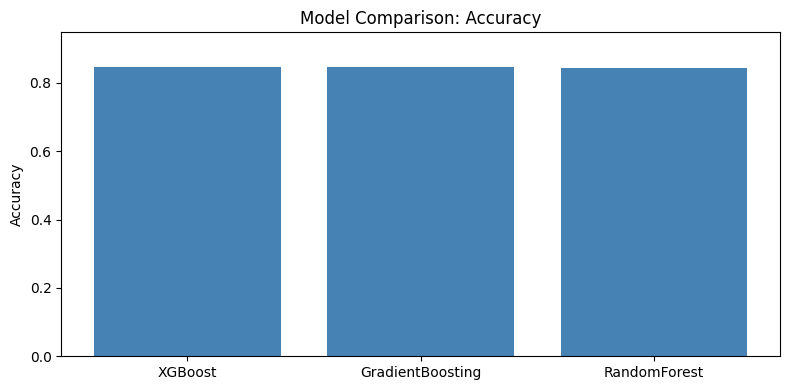

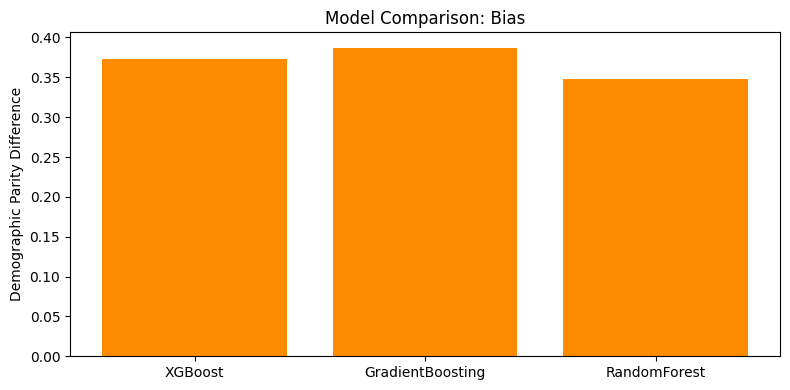

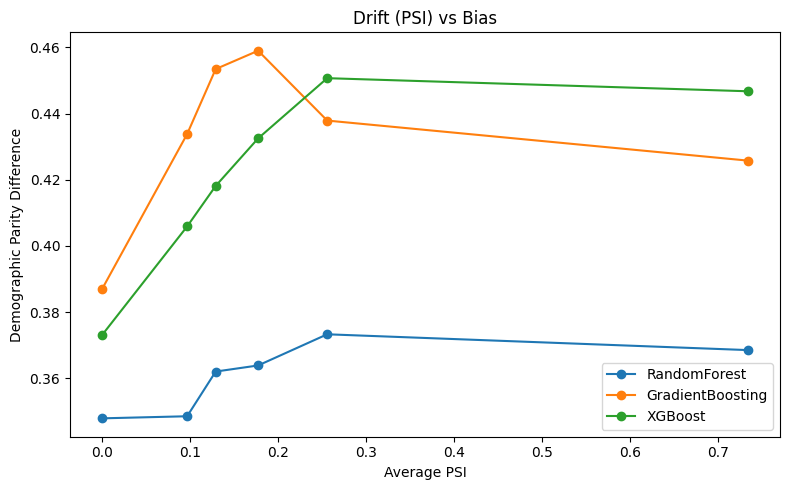

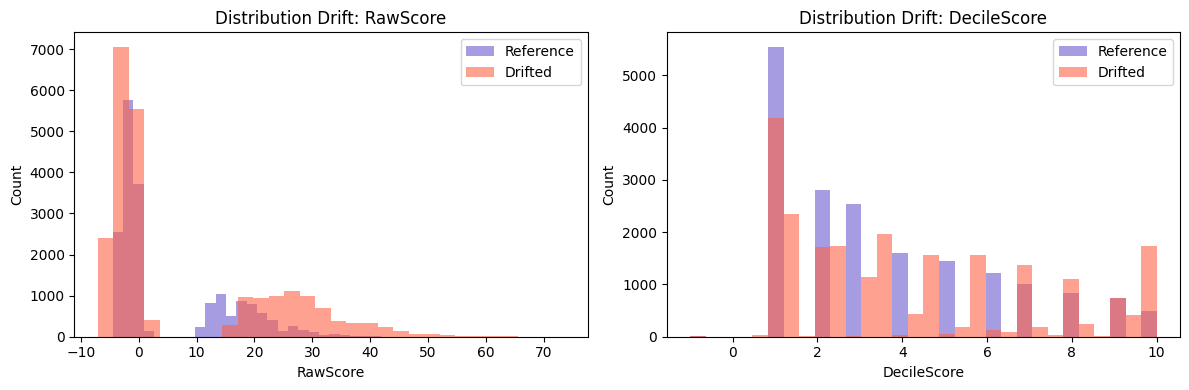

In [17]:
# Model comparison: baseline accuracy
plt.figure(figsize=(8, 4))
plt.bar(final_results["Model"], final_results["Accuracy"], color="steelblue")
plt.ylabel("Accuracy")
plt.title("Model Comparison: Accuracy")
plt.ylim(0, min(1.0, final_results["Accuracy"].max() + 0.1))
plt.tight_layout()
plt.show()

# Bias comparison: baseline demographic parity
plt.figure(figsize=(8, 4))
plt.bar(final_results["Model"], final_results["Bias"], color="darkorange")
plt.ylabel("Demographic Parity Difference")
plt.title("Model Comparison: Bias")
plt.tight_layout()
plt.show()

# Drift vs bias curve for each deployed model
plt.figure(figsize=(8, 5))
for model_name in drift_bias_results["Model"].unique():
    subset = drift_bias_results[drift_bias_results["Model"] == model_name].sort_values("Average PSI")
    plt.plot(subset["Average PSI"], subset["Demographic Parity"], marker="o", label=model_name)

plt.xlabel("Average PSI")
plt.ylabel("Demographic Parity Difference")
plt.title("Drift (PSI) vs Bias")
plt.legend()
plt.tight_layout()
plt.show()

# Feature distribution drift for the strongest drift level
fig, axes = plt.subplots(1, len(DRIFT_FEATURES), figsize=(12, 4))
if len(DRIFT_FEATURES) == 1:
    axes = [axes]

for ax, feature in zip(axes, DRIFT_FEATURES):
    ax.hist(reference_deployment[feature], bins=30, alpha=0.6, label="Reference", color="slateblue")
    ax.hist(X_drift_example[feature], bins=30, alpha=0.6, label="Drifted", color="tomato")
    ax.set_title(f"Distribution Drift: {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

## 18. Baseline vs Drifted Summary for the Highest Drift Level

In [18]:
comparison_table = baseline_results.merge(
    drifted_results,
    on="Model",
    suffixes=(" Before Drift", " After Drift"),
)
comparison_table

,Model,Accuracy Before Drift,Demographic Parity Before Drift,Equal Opportunity Before Drift,Positive Rate Before Drift,Accuracy After Drift,Demographic Parity After Drift,Equal Opportunity After Drift,Positive Rate After Drift,Drift Level
0,XGBoost,0.848025,0.373181,0.260624,0.315291,0.810929,0.446747,0.287027,0.432051,1.5
1,GradientBoosting,0.847806,0.387109,0.277682,0.319564,0.779468,0.425801,0.237502,0.508580,1.5
2,RandomForest,0.844519,0.347932,0.226784,0.312004,0.785275,0.368554,0.203755,0.463165,1.5
